The first thing is to create as sample data set of 10 housess with one outlier.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# creating the sample dataset
data ={'House_ID': [1,2,3,4,5,6,7,8,8,10],
    'Prices_Lira': [250000, 270000, 310000,240000,5000000,280000,300000,260000,290000,315000]
}
df =pd.DataFrame(data)
df.to_csv('house_prices.csv', index=False)
print("Dataset 'house_prices.csv' Success")

df= pd.read_csv('house_prices.csv')
print(df)

Dataset 'house_prices.csv' Success
   House_ID  Prices_Lira
0         1       250000
1         2       270000
2         3       310000
3         4       240000
4         5      5000000
5         6       280000
6         7       300000
7         8       260000
8         8       290000
9        10       315000


In [12]:
# loading the data and calculating the average
df= pd.read_csv('house_prices.csv')
attribute= df['Prices_Lira']
average_val = attribute.mean()
print(f'The average house prices is: {average_val:,.2f}')

The average house prices is: 751,500.00


In [19]:
# the next thing is calculating the Euclidean Distance from Average for each point
#Formula: |Value - Average|
df['DistanceFrom_Average']= np.abs(df['Prices_Lira']- average_val)

#Identifying the outlier, we define a threshold i.e points more than 2 Standard Deviations away
std_dev= attribute.std()
threshold =2 * std_dev
outlier =df[df['DistanceFrom_Average']>threshold]
print('Outliers',outlier)


Outliers    House_ID  Prices_Lira  DistanceFrom_Average
4         5      5000000             4248500.0


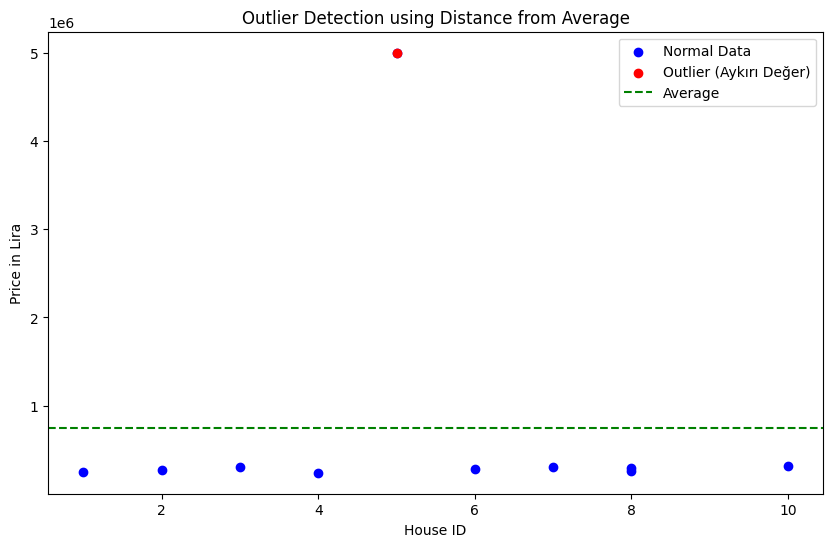

In [23]:
# visualisation
plt.figure(figsize=(10, 6))
plt.scatter(df['House_ID'], df['Prices_Lira'], color='blue', label='Normal Data')
plt.scatter(outlier['House_ID'], outlier['Prices_Lira'], color='red', label='Outlier (Aykırı Değer)')
plt.axhline(y=average_val, color='green', linestyle='--', label='Average')
plt.title('Outlier Detection using Distance from Average')
plt.xlabel('House ID')
plt.ylabel('Price in Lira')
plt.legend()
plt.show()

In [31]:
# Now we have to decide if we have to fix the outlier by discarding or replacing it with the average
# Since this looks like a typing error for 500,000 liras, we will just replace with the average
median_val =df['Prices_Lira'].median()
df_fix=df.copy()
df_fix.loc[df['DistanceFrom_Average']> threshold, 'Prices_Liras']=median_val
print (f'The outlier was replaced with the average value (${median_val:,.2f}).')

The outlier was replaced with the average value ($285,000.00).
